# Netflix Movies & TV Shows — Data Analysis

## Project Overview

This project explores the Netflix titles dataset using Python and Pandas to understand content distribution, genres, ratings, countries, release years, and other characteristics of movies and TV shows.

### Objectives

- Analyze the distribution of Movies and TV Shows
- Examine Netflix titles added over time
- Identify countries with the highest number of titles
- Analyze content ratings
- Explore movie durations and TV show seasons
- Identify popular genres
- Analyze directors and actors
- Compare Movies and TV Shows across different dimensions

### Tools & Technologies

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

### Dataset

Netflix Movies and TV Shows dataset containing information such as title, type, director, cast, country, date added, release year, rating, duration, and genre.


In [1]:
import pandas as pd

## 1. Data Loading

The Netflix titles dataset is loaded into a Pandas DataFrame for analysis.


In [2]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\USER\OneDrive\Desktop\projects\netflix_project\data\netflix_titles.csv.csv"
)

## 2. Initial Data Exploration

Before cleaning the dataset, the data is inspected to understand its structure, dimensions, data types, and missing values.


In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## 3. Data Cleaning & Preparation

The dataset was cleaned and transformed before performing exploratory analysis. This included handling missing values, correcting inconsistent rating values, extracting numerical duration information, and converting date fields into a usable format.


### 3.1 Handling Missing Values

Missing values in categorical columns were replaced with `"Unknown"` so that they could be retained during analysis without removing the corresponding titles.


In [9]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [10]:
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

In [11]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8807 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [13]:
df['type'].value_counts()
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [14]:
df[df['rating'].isin(['74 min', '84 min', '66 min'])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,Unknown,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,Unknown,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,Unknown,Movies,The comic puts his trademark hilarious/thought...


### 3.2 Correcting Inconsistent Rating Values

Three records contained movie durations such as `"74 min"`, `"84 min"`, and `"66 min"` in the `rating` column. These values were moved to the `duration` column and the incorrect rating entries were replaced with `"Unknown"`.


In [15]:
mask = df['rating'].isin(['74 min', '84 min', '66 min'])

df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = 'Unknown'

In [16]:
df.loc[mask, ['title', 'rating', 'duration']]

,title,rating,duration
5541,Louis C.K. 2017,Unknown,74 min
5794,Louis C.K.: Hilarious,Unknown,84 min
5813,Louis C.K.: Live at the Comedy Store,Unknown,66 min


In [17]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [18]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [19]:
df['duration'].value_counts().head(20)

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
92 min        129
102 min       122
98 min        120
99 min        118
88 min        116
101 min       116
103 min       114
106 min       111
100 min       108
89 min        106
Name: count, dtype: int64

In [20]:
df['duration'].value_counts().tail(20)

duration
253 min    1
208 min    1
5 min      1
16 min     1
186 min    1
193 min    1
10 min     1
3 min      1
312 min    1
214 min    1
43 min     1
200 min    1
196 min    1
167 min    1
178 min    1
228 min    1
18 min     1
205 min    1
201 min    1
191 min    1
Name: count, dtype: int64

In [21]:
df['duration'].value_counts().loc[lambda x: x.index == 'Unknown']

Series([], Name: count, dtype: int64)

### 3.3 Creating Numerical Duration Columns

The duration column contains both movie durations in minutes and TV show durations in seasons. Separate numerical columns were created to make these values easier to analyze.


In [22]:
df['duration_minutes'] = df['duration'].str.extract(r'(\d+) min')
df['duration_seasons'] = df['duration'].str.extract(r'(\d+) Season')

In [23]:
df['duration_minutes'] = pd.to_numeric(df['duration_minutes'])
df['duration_seasons'] = pd.to_numeric(df['duration_seasons'])

In [24]:
df[['type', 'title', 'duration', 'duration_minutes', 'duration_seasons']].head(10)

,type,title,duration,duration_minutes,duration_seasons
0,Movie,Dick Johnson Is Dead,90 min,90.0,NaN
1,TV Show,Blood & Water,2 Seasons,NaN,2.0
2,TV Show,Ganglands,1 Season,NaN,1.0
3,TV Show,Jailbirds New Orleans,1 Season,NaN,1.0
4,TV Show,Kota Factory,2 Seasons,NaN,2.0
5,TV Show,Midnight Mass,1 Season,NaN,1.0
6,Movie,My Little Pony: A New Generation,91 min,91.0,NaN
7,Movie,Sankofa,125 min,125.0,NaN
8,TV Show,The Great British Baking Show,9 Seasons,NaN,9.0
9,Movie,The Starling,104 min,104.0,NaN


In [25]:
df['duration_minutes'] = df['duration_minutes'].astype('Int64')
df['duration_seasons'] = df['duration_seasons'].astype('Int64')

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   show_id           8807 non-null   str  
 1   type              8807 non-null   str  
 2   title             8807 non-null   str  
 3   director          8807 non-null   str  
 4   cast              8807 non-null   str  
 5   country           8807 non-null   str  
 6   date_added        8807 non-null   str  
 7   release_year      8807 non-null   int64
 8   rating            8807 non-null   str  
 9   duration          8807 non-null   str  
 10  listed_in         8807 non-null   str  
 11  description       8807 non-null   str  
 12  duration_minutes  6131 non-null   Int64
 13  duration_seasons  2676 non-null   Int64
dtypes: Int64(2), int64(1), str(11)
memory usage: 980.6 KB


### 3.4 Date Transformation

The `date_added` column was converted into a datetime format. Year and month columns were then extracted to support time-based analysis.


In [27]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [28]:
df[['date_added']].head()

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24


In [29]:
df['date_added'].isnull().sum()

np.int64(98)

In [30]:
df[df['date_added'].isnull()][['show_id', 'title', 'date_added']].head(20)

,show_id,title,date_added
6066,s6067,A Young Doctor's Notebook and Other Stories,NaT
6079,s6080,Abnormal Summit,NaT
6174,s6175,Anthony Bourdain: Parts Unknown,NaT
6177,s6178,忍者ハットリくん,NaT
6213,s6214,Bad Education,NaT
6279,s6280,Being Mary Jane: The Series,NaT
6304,s6305,"Big Dreams, Small Spaces",NaT
6318,s6319,Bitten,NaT
6357,s6358,Bondi Rescue,NaT
6361,s6362,Borderline,NaT


In [31]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [32]:
df['date_added'].dtype

dtype('<M8[us]')

In [33]:
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month

In [34]:
df[['date_added', 'added_year', 'added_month']].head()

,date_added,added_year,added_month
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


In [35]:
df['added_year'] = df['added_year'].astype('Int64')
df['added_month'] = df['added_month'].astype('Int64')

In [36]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [37]:
df['type'].value_counts(normalize=True) * 100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

In [38]:
import sys
print(sys.executable)

C:\Users\USER\.conda\envs\notebook-env\python.exe


In [39]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [40]:
import matplotlib
print(matplotlib.__version__)

3.11.2


In [41]:
import matplotlib.pyplot as plt

## 4. Exploratory Data Analysis

The cleaned Netflix dataset was analyzed to identify patterns and trends in its content library. The analysis focuses on content type, titles added over time, countries, ratings, duration, genres, directors, actors, and relationships between different attributes.


### 4.1 Movies vs TV Shows

This analysis compares the distribution of Movies and TV Shows in the Netflix dataset to understand the composition of the content library.

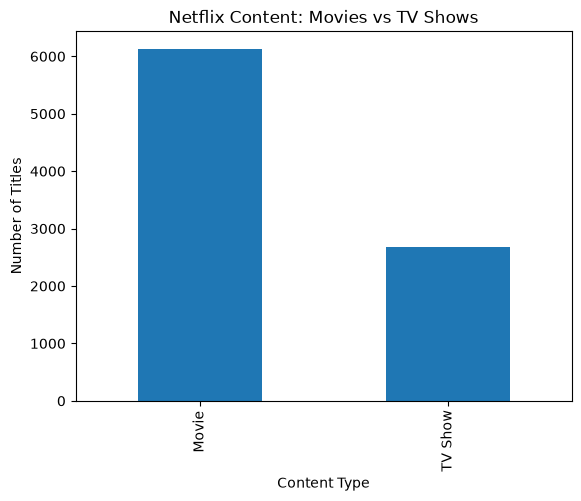

In [42]:
df['type'].value_counts().plot(
    kind='bar',
    title='Netflix Content: Movies vs TV Shows'
)

plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

**Insight:** Movies represent the larger share of titles in the Netflix dataset, while TV Shows account for a smaller proportion of the overall content library.

In [43]:
df['date_added'].isnull().sum()

np.int64(98)

### 4.2 Titles Added Over Time

This analysis examines how the number of Netflix titles added to the dataset changed over the years.

In [44]:
pd.to_datetime(df['date_added'], errors='coerce')

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[us]

In [45]:
df[df['date_added'].isna()][['show_id', 'title', 'date_added']].head(10)

,show_id,title,date_added
6066,s6067,A Young Doctor's Notebook and Other Stories,NaT
6079,s6080,Abnormal Summit,NaT
6174,s6175,Anthony Bourdain: Parts Unknown,NaT
6177,s6178,忍者ハットリくん,NaT
6213,s6214,Bad Education,NaT
6279,s6280,Being Mary Jane: The Series,NaT
6304,s6305,"Big Dreams, Small Spaces",NaT
6318,s6319,Bitten,NaT
6357,s6358,Bondi Rescue,NaT
6361,s6362,Borderline,NaT


In [46]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\USER\OneDrive\Desktop\projects\netflix_project\data\netflix_titles.csv.csv"
)

In [47]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    format='%B %d, %Y',
    errors='coerce'
)

In [48]:
df['date_added'].isna().sum()

np.int64(98)

#### Number of Netflix Titles Added by Year

In [49]:
df[df['date_added'].isna()][['show_id', 'title', 'date_added']].head(10)

,show_id,title,date_added
6066,s6067,A Young Doctor's Notebook and Other Stories,NaT
6079,s6080,Abnormal Summit,NaT
6174,s6175,Anthony Bourdain: Parts Unknown,NaT
6177,s6178,忍者ハットリくん,NaT
6213,s6214,Bad Education,NaT
6279,s6280,Being Mary Jane: The Series,NaT
6304,s6305,"Big Dreams, Small Spaces",NaT
6318,s6319,Bitten,NaT
6357,s6358,Bondi Rescue,NaT
6361,s6362,Borderline,NaT


In [50]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    format='%B %d, %Y',
    errors='coerce'
)

In [51]:
df['date_added'].isna().sum()

np.int64(98)

In [52]:
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month

In [53]:
df[['date_added', 'added_year', 'added_month']].head()

,date_added,added_year,added_month
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


In [54]:
df['added_year'] = df['added_year'].astype('Int64')
df['added_month'] = df['added_month'].astype('Int64')

In [55]:
df[['date_added', 'added_year', 'added_month']].head()

,date_added,added_year,added_month
0,2021-09-25,2021,9
1,2021-09-24,2021,9
2,2021-09-24,2021,9
3,2021-09-24,2021,9
4,2021-09-24,2021,9


In [56]:
df['added_year'].value_counts().sort_index()

added_year
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: Int64

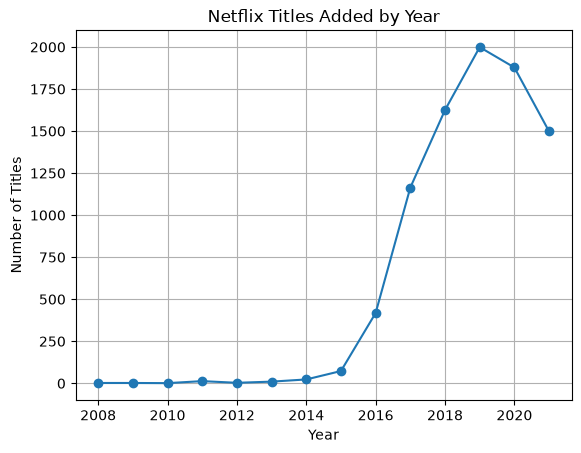

In [57]:
yearly_counts = df['added_year'].value_counts().sort_index()

yearly_counts.plot(
    kind='line',
    marker='o',
    title='Netflix Titles Added by Year'
)

import matplotlib.pyplot as plt

plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

**Insight:** The number of titles added to Netflix increased substantially over the years, with the dataset showing particularly high additions during the later years.

#### Movies vs TV Shows Added by Year
This analysis compares the number of Movies and TV Shows added to Netflix across different years.

In [58]:
year_type.plot(
    kind='line',
    marker='o',
    title='Netflix Movies vs TV Shows Added by Year'
)

import matplotlib.pyplot as plt

plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.legend(title='Type')
plt.show()

NameError: name 'year_type' is not defined

**Insight:** Movies were generally added in greater numbers than TV Shows across most years, although the number of TV Shows also increased over time.

### 4.3 Country Analysis

This analysis identifies the countries with the highest representation in the Netflix dataset and provides an overview of the geographical distribution of Netflix content.

In [ ]:
year_type = df.groupby(['added_year', 'type']).size().unstack(fill_value=0)

year_type

In [ ]:
country_df = df[df['country'] != 'Unknown'].copy()

country_df['country'] = country_df['country'].str.split(', ')

country_exploded = country_df.explode('country')

In [ ]:
country_exploded[['title', 'country']].head(10)

In [ ]:
country_exploded = country_exploded.dropna(subset=['country'])

#### Top 10 Countries Represented in the Netflix Dataset

In [ ]:
country_counts = country_exploded['country'].value_counts()

country_counts.head(10)

In [ ]:
country_counts.head(10).sort_values().plot(
    kind='barh',
    title='Top 10 Countries by Netflix Titles'
)

plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

**Insight:** The United States has the highest number of titles in the dataset, followed by other major content-producing countries.

### 4.4 Ratings Analysis

This analysis examines the distribution of Netflix content ratings and compares the ratings of Movies and TV Shows.

In [ ]:
rating_type = df.groupby(['rating', 'type']).size().unstack(fill_value=0)

rating_type

In [ ]:
mask = df['rating'].isin(['74 min', '84 min', '66 min'])

df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = 'Unknown'

In [ ]:
df['rating'].value_counts()

**Insight:** TV-MA is the most common content rating in the dataset, indicating that mature-rated content forms a significant part of the Netflix catalog.

#### Netflix Ratings by Content Type

In [ ]:
rating_type = df.groupby(['rating', 'type']).size().unstack(fill_value=0)

rating_type

In [ ]:
rating_type.plot(
    kind='bar',
    figsize=(12, 6),
    title='Netflix Ratings by Content Type'
)

plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')
plt.show()

**Insight:** The distribution of ratings differs between Movies and TV Shows, with some ratings appearing more frequently for one content type than the other.

### 4.5 Duration Analysis

This analysis explores the duration of Netflix Movies and the number of seasons associated with TV Shows.

In [ ]:
df['duration_minutes'] = df['duration'].str.extract(r'(\d+) min')
df['duration_seasons'] = df['duration'].str.extract(r'(\d+) Season')

df['duration_minutes'] = pd.to_numeric(df['duration_minutes'])
df['duration_seasons'] = pd.to_numeric(df['duration_seasons'])

df['duration_minutes'] = df['duration_minutes'].astype('Int64')
df['duration_seasons'] = df['duration_seasons'].astype('Int64')

#### Distribution of Movie Durations

This analysis examines the distribution of movie runtimes in minutes to identify the most common movie durations.

In [ ]:
df[['type', 'duration', 'duration_minutes', 'duration_seasons']].head(10)

In [ ]:
movie_duration = df[df['type'] == 'Movie']['duration_minutes']

movie_duration.describe()

In [ ]:
movie_duration.plot(
    kind='hist',
    bins=30,
    title='Distribution of Netflix Movie Durations',
    figsize=(10, 6)
)

plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.show()

**Insight:** Most Netflix movies fall within a moderate runtime range, with relatively fewer titles having very short or very long durations.

#### Distribution of TV Show Seasons

This analysis examines the number of seasons of Netflix TV Shows to understand the typical length of TV series in the dataset.

In [ ]:
tv_seasons = df[df['type'] == 'TV Show']['duration_seasons']

tv_seasons.describe()

In [ ]:
tv_seasons.plot(
    kind='hist',
    bins=17,
    title='Distribution of Netflix TV Show Seasons',
    figsize=(10, 6)
)

plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.show()

**Insight:** TV Shows in the dataset generally have a small number of seasons. The average number of seasons is approximately 1.76, indicating that many shows have one or two seasons.

### 4.6 Genre Analysis

This analysis identifies the most frequently represented genres in the Netflix dataset and provides an overview of the types of content available.

In [ ]:
genre_df = df.copy()

genre_df['listed_in'] = genre_df['listed_in'].str.split(', ')

genre_exploded = genre_df.explode('listed_in')

In [ ]:
genre_exploded[['title', 'listed_in']].head(10)

#### Top 10 Netflix Genres

In [ ]:
genre_counts = genre_exploded['listed_in'].value_counts()

genre_counts.head(10)

In [ ]:
genre_counts.head(10).sort_values().plot(
    kind='barh',
    title='Top 10 Netflix Genres',
    figsize=(10, 6)
)

plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

**Insight:** The most frequently represented genre is International movies, followed by Dramas and Comedies.

### 4.7 Director and Actor Analysis

This analysis examines the directors and actors who appear most frequently in the Netflix dataset.

#### Top 10 Directors by Number of Titles

This analysis identifies the directors associated with the highest number of titles in the dataset.

In [ ]:
director_counts = (
    df[df['director'] != 'Unknown']['director']
    .value_counts()
)

director_counts.head(10)

In [ ]:
director_counts.head(10).sort_values().plot(
    kind='barh',
    title='Top 10 Directors by Number of Netflix Titles',
    figsize=(10, 6)
)

plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

**Insight:** A relatively small group of directors appears across multiple Netflix titles, while most directors are associated with fewer titles.

#### Top 10 Actors by Number of Titles

This analysis identifies the actors who appear in the highest number of titles in the Netflix dataset.

In [ ]:
cast_df = df[df['cast'] != 'Unknown'].copy()

cast_df['cast'] = cast_df['cast'].str.split(', ')

cast_exploded = cast_df.explode('cast')

cast_exploded.head()

In [ ]:
actor_counts = cast_exploded['cast'].value_counts()

actor_counts.head(10)

In [ ]:
actor_counts.head(10).sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 10 Actors by Number of Netflix Titles'
)

plt.xlabel('Number of Titles')
plt.ylabel('Actor')
plt.show()

**Insight:** Several actors appear across multiple Netflix titles, showing that some performers have a recurring presence within the dataset.

### 4.8 Release Year Analysis

This analysis examines the distribution of Netflix titles according to their original release year to understand the age and recency of the content in the dataset.

#### Netflix Titles by Release Year

In [ ]:
release_year_counts = df['release_year'].value_counts().sort_index()

release_year_counts.tail(10)

In [ ]:
release_year_counts.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    title='Netflix Titles by Original Release Year'
)

plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

**Insight:** The dataset contains titles released across several decades, but a large proportion of the catalog consists of more recent releases.

#### Movies vs TV Shows by Release Year

This analysis compares the number of Movies and TV Shows across different release years.

In [ ]:
release_type = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

release_type.tail(10)

In [ ]:
release_type.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    title='Netflix Movies vs TV Shows by Original Release Year'
)

plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.legend(title='Content Type')
plt.show()

**Insight:** Movies account for a larger number of titles across most release years, while TV Shows become more prominent in the more recent years represented in the dataset.

#### Shows added by month
This analysis compares the number of Movies and TV Shows across different release months.

In [ ]:
month_counts = df['added_month'].value_counts().sort_index()

month_counts

In [ ]:
month_counts.plot(
    kind='bar',
    figsize=(10, 6),
    title='Netflix Titles Added by Month'
)

plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.show()

### 4.9 Country and Content Type Analysis

This analysis compares the distribution of Movies and TV Shows across countries to identify differences in content type by geographical region.

In [ ]:
country_type = (
    country_exploded
    .groupby(['country', 'type'])
    .size()
    .unstack(fill_value=0)
)

country_type.head(10)

In [ ]:
country_type = country_type[country_type.index != '']

#### Movies vs TV Shows by Country

In [ ]:
country_totals = country_type.sum(axis=1).sort_values(ascending=False)

country_totals.head(10)

In [ ]:
top_countries = country_totals.head(10).index

country_type_top10 = country_type.loc[top_countries]

country_type_top10

In [ ]:
country_type_top10.plot(
    kind='bar',
    figsize=(12, 6),
    title='Netflix Movies vs TV Shows by Top 10 Countries'
)

plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')
plt.show()

#### Duration by year

In [ ]:
avg_movie_duration = (
    df[df['type'] == 'Movie']
    .groupby('release_year')['duration_minutes']
    .mean()
)

avg_movie_duration.tail(15)

In [ ]:
avg_movie_duration.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    title='Average Movie Duration by Release Year'
)

plt.xlabel('Release Year')
plt.ylabel('Average Duration (Minutes)')
plt.grid(True)
plt.show()

**Insight:** The balance between Movies and TV Shows varies across countries, with some countries contributing primarily Movies while others have a relatively larger share of TV Shows.

### 4.10 Genre and Content Type Analysis

This analysis examines the most common genres separately for Movies and TV Shows to identify differences in content preferences and composition.

In [ ]:
genre_type = (
    genre_exploded
    .groupby(['listed_in', 'type'])
    .size()
    .unstack(fill_value=0)
)

genre_type.head(10)

#### Top Movie Genres

This analysis identifies the most frequently represented genres among Netflix Movies.

In [ ]:
top_movie_genres = genre_type['Movie'].sort_values(ascending=False).head(10)

top_tv_genres = genre_type['TV Show'].sort_values(ascending=False).head(10)

print("Top 10 Movie Genres:")
print(top_movie_genres)

print("\nTop 10 TV Show Genres:")
print(top_tv_genres)

In [ ]:
top_movie_genres.sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 10 Movie Genres on Netflix'
)

plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

**Insight:** Movies are distributed across a wide range of genres, with a few genres appearing substantially more frequently than others.

#### Top TV Show Genres

This analysis identifies the most frequently represented genres among Netflix TV Shows.

In [ ]:
top_tv_genres.sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 10 TV Show Genres on Netflix'
)

plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

**Insight:** TV Shows also cover a diverse range of genres, with certain genres appearing more frequently than others.

### 4.11 Dataset Overview & Summary Statistics

#### Overall Dataset Summary & Content Metrics

This section provides a high-level overview of the Netflix dataset using key summary metrics. It covers the total number of titles, distribution of Movies and TV Shows, average content duration, number of TV Show seasons, and the range of release years.

In [ ]:
total_titles = len(df)

total_movies = (df['type'] == 'Movie').sum()

total_tv_shows = (df['type'] == 'TV Show').sum()

avg_movie_duration = df.loc[
    df['type'] == 'Movie',
    'duration_minutes'
].mean()

avg_tv_seasons = df.loc[
    df['type'] == 'TV Show',
    'duration_seasons'
].mean()

earliest_release_year = df['release_year'].min()

latest_release_year = df['release_year'].max()

print("Total Titles:", total_titles)
print("Total Movies:", total_movies)
print("Total TV Shows:", total_tv_shows)
print("Average Movie Duration:", round(avg_movie_duration, 2), "minutes")
print("Average TV Show Seasons:", round(avg_tv_seasons, 2))
print("Earliest Release Year:", earliest_release_year)
print("Latest Release Year:", latest_release_year)

**Key Insights:**

- The dataset contains **8,807 titles**, including **6,131 Movies** and **2,676 TV Shows**.
- Movies account for **69.62%** of the dataset, while TV Shows account for **30.38%**.
- The average Movie duration is approximately **99.56 minutes**.
- TV Shows have an average of **1.76 seasons**.
- The dataset contains titles released between **1925 and 2021**.

### 4.12 High-Level Metric Insights

#### Content Type Proportions & Peak Content Additions

This analysis examines the proportion of Movies and TV Shows in the dataset and identifies the year in which the highest number of Netflix titles were added.

In [ ]:
type_percentage = df['type'].value_counts(normalize=True) * 100

print(type_percentage.round(2))

In [ ]:
peak_added_year = yearly_counts.idxmax()
peak_added_count = yearly_counts.max()

print("Peak year:", peak_added_year)
print("Titles added:", peak_added_count)

**Key Insights:**

- Movies represent **69.62%** of the dataset, compared with **30.38%** for TV Shows.
- The highest number of titles were added in **2019**, with **1,999 titles** added during that year.
- The results show that Movies form a substantially larger portion of the dataset than TV Shows.

#### Country Dominance Analysis

This analysis identifies the country with the highest number of titles in the dataset and measures its share of the overall Netflix catalog.

In [ ]:
top_country = country_counts.idxmax()
top_country_count = country_counts.max()

print("Top country:", top_country)
print("Number of titles:", top_country_count)
print("Percentage of titles:", round((top_country_count / len(df)) * 100, 2), "%")

In [ ]:
top_genre = genre_counts.idxmax()
top_genre_count = genre_counts.max()

print("Top genre:", top_genre)
print("Number of titles:", top_genre_count)

**Key Insights:**

- The **United States** is the most represented country in the dataset, with **3,689 titles**.
- These titles account for approximately **41.89%** of the dataset.
- This indicates that titles associated with the United States make up a substantial portion of the Netflix catalog represented in this dataset.

### 4.13 Detailed Duration & Rating Insights

#### Movie and TV Show Duration Medians

This analysis compares the average and median duration of Movies and TV Shows to understand the typical length of content in the dataset.

In [ ]:
movie_median = movie_duration.median()

print("Average movie duration:", round(movie_duration.mean(), 2), "minutes")
print("Median movie duration:", round(movie_median, 2), "minutes")

In [ ]:
tv_median_seasons = tv_seasons.median()

print("Average TV show seasons:", round(tv_seasons.mean(), 2))
print("Median TV show seasons:", round(tv_median_seasons, 2))

**Key Insights:**

- The average Movie duration is **99.56 minutes**, while the median duration is **98 minutes**.
- The average TV Show has **1.76 seasons**, while the median is **1 season**.
- The median values indicate that a typical Movie in the dataset is approximately 98 minutes long, while a typical TV Show has one season.
- The difference between the average and median number of TV Show seasons suggests that some shows with multiple seasons increase the average.

#### Genre & Content Rating Summaries

This section summarizes the most frequently represented genre and the most common content rating in the Netflix dataset.

In [ ]:
top_rating = df['rating'].value_counts().idxmax()
top_rating_count = df['rating'].value_counts().max()

print("Most common rating:", top_rating)
print("Number of titles:", top_rating_count)

**Key Insights:**

- **International Movies** is the most frequently represented genre, with **2,752 titles**.
- **TV-MA** is the most common content rating, with **3,207 titles**.
- These results highlight the strong representation of international movie content and mature-rated titles within the dataset.

## 5. Key Insights

The exploratory analysis of the Netflix dataset revealed several important patterns and characteristics of the content library.

### 5.1 Content Distribution

- The dataset contains **8,807 titles**, consisting of **6,131 Movies** and **2,676 TV Shows**.
- Movies account for **69.62%** of the dataset, while TV Shows account for **30.38%**.

### 5.2 Content Added Over Time

- The highest number of titles were added in **2019**, with **1,999 titles** added during the year.
- The number of titles added increased considerably during the later years represented in the dataset.

### 5.3 Country Representation

- The **United States** is the most represented country, with **3,689 titles**, accounting for approximately **41.89%** of the dataset.
- Netflix content in the dataset is geographically diverse, with titles associated with many different countries.

### 5.4 Ratings

- **TV-MA** is the most common content rating, with **3,207 titles**.
- The distribution of ratings varies between Movies and TV Shows.

### 5.5 Duration

- Movies have an average duration of **99.56 minutes** and a median duration of **98 minutes**.
- TV Shows have an average of **1.76 seasons**, while the median is **1 season**.

### 5.6 Genres

- **International Movies** is the most frequently represented genre, with **2,752 titles**.
- The dataset contains a wide variety of genres across both Movies and TV Shows.

### 5.7 Overall Observation

Overall, the analysis shows that the Netflix dataset is dominated by Movies, contains substantial international content, and includes a wide variety of genres and ratings. The later years in the dataset also show a significant increase in the number of titles added.

## 6. Conclusion

This project explored the Netflix Movies and TV Shows dataset using Python, Pandas, and Matplotlib. The analysis examined content types, countries, ratings, genres, duration, release years, directors, and actors.

The analysis provided insights into the composition and characteristics of the Netflix content library. It also demonstrated the use of data cleaning, exploratory data analysis, statistical summaries, data aggregation, and visualization techniques.

Through this project, I strengthened my practical skills in Python-based data analysis and learned how to transform a raw dataset into meaningful insights.